# 04 - Statistical Analysis

This notebook performs statistical analysis on the Amsterdam Inside Airbnb dataset.

The goal is to test whether important market differences observed during EDA are statistically meaningful.

Main analysis areas:
- Price differences across room types
- Price differences across host portfolio segments
- Occupancy proxy differences across room types
- Review score differences across room types
- Correlation significance between price and key listing features

In [2]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
    --------------------------------------- 0.5/37.3 MB 995.0 kB/s eta 0:00:37
   - -------------------------------------- 1.8/37.3 MB 2.7 MB/s eta 0:00:14
   -- ------------------------------------- 2.6/37.3 MB 3.1 MB/s eta 0:00:12
   ---- ----------------------------------- 3.9/37.3 MB 3.7 MB/s eta 0:00:09
   ----- ---------------------------------- 5.2/37.3 MB 4.2 MB/s eta 0:00:08
   ------- -------------------------------- 6.8/37.3 MB 4.7 MB/s eta 0:00:07
   --------- ------------------------------ 8.7/37.3 MB 5.2 MB/s eta 0:00:06
   ---------- ----------------------------- 10.2/37.3 MB 5.4 MB/s eta 0:00:05
   ------------ --------------------------- 11.8/37.3 MB 5.7 MB/s eta 0:00:05
   ------------

In [3]:
import scipy
print("SciPy version:", scipy.__version__)

SciPy version: 1.18.0


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path("..")

WAREHOUSE_PATH = PROJECT_ROOT / "warehouse"
DUCKDB_DATABASE_PATH = WAREHOUSE_PATH / "airbnb_market.duckdb"

STAT_REPORTS_PATH = PROJECT_ROOT / "reports" / "statistical_analysis"
STAT_REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("DuckDB database exists:", DUCKDB_DATABASE_PATH.exists())
print("Statistical reports path:", STAT_REPORTS_PATH)

DuckDB database exists: True
Statistical reports path: ..\reports\statistical_analysis


In [4]:
conn = duckdb.connect(
    database=str(DUCKDB_DATABASE_PATH),
    read_only=True
)

print("Connected to DuckDB in read-only mode.")

Connected to DuckDB in read-only mode.


In [5]:
listing_master_df = conn.execute("""
SELECT *
FROM listing_master_final
""").fetchdf()

print("listing_master_df shape:", listing_master_df.shape)
listing_master_df.head()

listing_master_df shape: (10465, 101)


,listing_id,listing_name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city,country,snapshot_date,host_is_superhost,host_response_time,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,property_type,accommodates,bathrooms_text,bedrooms,beds,amenities,amenities_count,instant_bookable,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_since,host_identity_verified,bathrooms,availability_30,availability_60,availability_90,number_of_reviews_l30d,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,calendar_days,available_days,unavailable_days,weekend_available_days,weekend_total_days,weekday_available_days,weekday_total_days,avg_minimum_nights,median_minimum_nights,avg_maximum_nights,median_maximum_nights,availability_rate,occupancy_proxy,weekend_availability_rate,weekday_availability_rate,listing_price_available_flag,price_numeric,unavailable_days_numeric,estimated_revenue_proxy,host_portfolio_segment,availability_segment,detailed_review_count,unique_reviewer_count,first_detailed_review_date,latest_detailed_review_date,reviews_with_comments,avg_comment_length,median_comment_length,detailed_reviews_last_365d,comment_coverage_rate,review_history_days,review_history_years,avg_reviews_per_year,has_reviews,neighbourhood_listing_count,neighbourhood_unique_hosts,neighbourhood_avg_price,neighbourhood_median_price,neighbourhood_min_price,neighbourhood_max_price,neighbourhood_avg_availability_rate,neighbourhood_avg_occupancy_proxy,neighbourhood_avg_review_score,neighbourhood_total_reviews,neighbourhood_avg_reviews_per_listing,neighbourhood_total_revenue_proxy,neighbourhood_avg_revenue_proxy,neighbourhood_dominant_room_type
0,28871,Comfortable double room,124245,1462510208428038912,Edwin,<NA>,Centrum-West,52.367750,4.89092,Private room,94.0,1.0,799,2026-06-01,4.15,2.0,11,88,0363 607B EA74 0BD8 2F6F,Amsterdam,Netherlands,2026-06-15,True,<NA>,<NA>,<NA>,2.0,NaN,Private room in rental unit,2.0,1 shared bath,NaN,NaN,"[""Heating"", ""Fire extinguisher"", ""Hot water"", ...",18.0,<NA>,4.86,4.89,4.84,4.94,4.94,4.93,4.83,NaT,True,NaN,1.0,1.0,1.0,5.0,95.0,255.0,23970.0,365,11,354,5,104,6,261,1.994521,2.0,730.0,730.0,0.0301,0.9699,0.0481,0.0230,True,94.0,354,33276.0,Small portfolio host,Low availability,799,796,2010-08-22,2026-06-01,799,202.556946,163.0,89,1.0,5776.0,15.81,50.54,True,1217,923,398.36,290.0,39.0,11412.0,0.34,0.66,4.82,116784,95.96,65092219.0,74221.46,Entire home/apt
1,29051,Comfortable single / double room,124245,1462510208428038912,Edwin,<NA>,Centrum-Oost,52.365840,4.89111,Private room,NaN,1.0,906,2026-06-01,4.88,2.0,2,82,0363 607B EA74 0BD8 2F6F,Amsterdam,Netherlands,2026-06-15,True,<NA>,<NA>,<NA>,2.0,NaN,Private room in condo,2.0,1 shared bath,NaN,NaN,"[""Heating"", ""Fire extinguisher"", ""Hot water"", ...",18.0,<NA>,4.82,4.88,4.83,4.93,4.93,4.88,4.79,NaT,True,NaN,0.0,2.0,2.0,6.0,85.0,255.0,NaN,365,2,363,1,104,1,261,1.980822,2.0,730.0,730.0,0.0055,0.9945,0.0096,0.0038,False,NaN,363,NaN,Small portfolio host,Low availability,906,894,2011-03-16,2026-06-01,906,241.263797,183.5,82,1.0,5570.0,15.25,59.41,True,933,708,350.41,282.5,39.0,2477.0,0.36,0.64,4.81,85025,91.13,44237061.0,65246.40,Entire home/apt
2,44129,Luxury design with canal view,187728,1462512125293144576,Tanya,<NA>,Centrum-West,52.382110,4.88630,Entire home/apt,314.0,3.0,186,2026-04-30,0.96,4.0,3,5,03635399E87602900F47,Amsterdam,Netherlands,2026-06-15,True,<NA>,<NA>,<NA>,6.0,NaN,Entire rental unit,2.0,1.5 baths,1.0,NaN,"[""Smoking allowed"", ""Extra pillows and blanket...",32.0,<NA>,4.88,4.81,4.88,4.89,4.89,4.95,4.59,NaT,True,NaN,3.0,3.0,3.0,0.0,1.0,39.0,12233.0,365,3,362,1,104,2,261,4.983562,5.0,1125.0,1125.0,0.00

In [6]:
stats_price_df = listing_master_df[
    listing_master_df["price_numeric"].notna() &
    (listing_master_df["price_numeric"] > 0)
].copy()

print("Total listings:", len(listing_master_df))
print("Listings with valid price:", len(stats_price_df))
print("Missing/invalid price listings:", len(listing_master_df) - len(stats_price_df))

Total listings: 10465
Listings with valid price: 6471
Missing/invalid price listings: 3994


## Statistical Test Plan

The dataset contains skewed price distributions and visible outliers.  
Because of this, non-parametric tests are preferred for many comparisons.

Planned tests:
1. Kruskal-Wallis test for price differences across room types.
2. Kruskal-Wallis test for price differences across host portfolio segments.
3. Kruskal-Wallis test for occupancy proxy differences across room types.
4. Spearman correlation tests for price and selected numeric features.

Kruskal-Wallis is used instead of one-way ANOVA because price is not normally distributed and contains outliers.

## 1. Price Differences Across Room Types

This test checks whether listing prices are significantly different across room types.

A Kruskal-Wallis test is used because price is right-skewed and contains outliers.  
This non-parametric test compares whether price distributions differ across more than two independent groups.

In [7]:
room_type_price_summary = (
    stats_price_df
    .groupby("room_type")
    .agg(
        listing_count=("price_numeric", "count"),
        mean_price=("price_numeric", "mean"),
        median_price=("price_numeric", "median"),
        min_price=("price_numeric", "min"),
        max_price=("price_numeric", "max")
    )
    .reset_index()
)

room_type_price_summary["mean_price"] = room_type_price_summary["mean_price"].round(2)
room_type_price_summary["median_price"] = room_type_price_summary["median_price"].round(2)

room_type_price_summary

,room_type,listing_count,mean_price,median_price,min_price,max_price
0,Entire home/apt,4771,394.62,331.0,26.0,11412.0
1,Hotel room,26,249.85,227.5,69.0,700.0
2,Private room,1653,203.67,171.0,15.0,1712.0
3,Shared room,21,80.10,52.0,31.0,681.0


In [8]:
room_type_groups = []

for room_type in stats_price_df["room_type"].dropna().unique():
    group_prices = stats_price_df[
        stats_price_df["room_type"] == room_type
    ]["price_numeric"].dropna()
    
    room_type_groups.append(group_prices)

kruskal_statistic, kruskal_p_value = stats.kruskal(*room_type_groups)

room_type_price_test_result = pd.DataFrame({
    "test_name": ["Kruskal-Wallis"],
    "comparison": ["Price by room type"],
    "test_statistic": [kruskal_statistic],
    "p_value": [kruskal_p_value]
})

room_type_price_test_result

,test_name,comparison,test_statistic,p_value
0,Kruskal-Wallis,Price by room type,1839.304703,0.0


In [9]:
n = len(stats_price_df)
k = stats_price_df["room_type"].nunique()

epsilon_squared = (kruskal_statistic - k + 1) / (n - k)

room_type_price_test_result["epsilon_squared"] = round(epsilon_squared, 4)

room_type_price_test_result

,test_name,comparison,test_statistic,p_value,epsilon_squared
0,Kruskal-Wallis,Price by room type,1839.304703,0.0,0.284


In [10]:
room_type_price_summary_output_path = STAT_REPORTS_PATH / "room_type_price_summary.csv"
room_type_price_test_output_path = STAT_REPORTS_PATH / "room_type_price_kruskal_test.csv"

room_type_price_summary.to_csv(room_type_price_summary_output_path, index=False)
room_type_price_test_result.to_csv(room_type_price_test_output_path, index=False)

print(f"Room type price summary saved to: {room_type_price_summary_output_path}")
print(f"Room type price test result saved to: {room_type_price_test_output_path}")

Room type price summary saved to: ..\reports\statistical_analysis\room_type_price_summary.csv
Room type price test result saved to: ..\reports\statistical_analysis\room_type_price_kruskal_test.csv


### Interpretation

The Kruskal-Wallis test was used to evaluate whether listing prices differ across room types.

If the p-value is below 0.05, the result suggests that at least one room type has a significantly different price distribution compared with the others.

This test does not identify exactly which room types differ from each other.  
Pairwise post-hoc testing would be required for that, but the result provides statistical support for the EDA finding that room type is associated with pricing differences.

### Pairwise Room Type Price Comparisons

Because the Kruskal-Wallis test showed a statistically significant price difference across room types, pairwise Mann-Whitney U tests are used to identify which room type pairs differ.

Bonferroni correction is applied to control the risk of false positives from multiple comparisons.

In [11]:
from itertools import combinations

room_types = stats_price_df["room_type"].dropna().unique()

pairwise_results = []

for room_type_1, room_type_2 in combinations(room_types, 2):
    group_1 = stats_price_df[
        stats_price_df["room_type"] == room_type_1
    ]["price_numeric"].dropna()
    
    group_2 = stats_price_df[
        stats_price_df["room_type"] == room_type_2
    ]["price_numeric"].dropna()
    
    u_statistic, p_value = stats.mannwhitneyu(
        group_1,
        group_2,
        alternative="two-sided"
    )
    
    n1 = len(group_1)
    n2 = len(group_2)
    
    rank_biserial_correlation = (2 * u_statistic) / (n1 * n2) - 1
    
    pairwise_results.append({
        "group_1": room_type_1,
        "group_2": room_type_2,
        "group_1_count": n1,
        "group_2_count": n2,
        "group_1_median_price": group_1.median(),
        "group_2_median_price": group_2.median(),
        "median_difference_group_1_minus_group_2": group_1.median() - group_2.median(),
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial_correlation": rank_biserial_correlation
    })

pairwise_room_type_price_tests = pd.DataFrame(pairwise_results)

# Bonferroni correction
number_of_tests = len(pairwise_room_type_price_tests)

pairwise_room_type_price_tests["p_value_bonferroni"] = (
    pairwise_room_type_price_tests["p_value"] * number_of_tests
).clip(upper=1)

pairwise_room_type_price_tests["significant_after_bonferroni"] = (
    pairwise_room_type_price_tests["p_value_bonferroni"] < 0.05
)

# Round numeric columns for readability
round_columns = [
    "group_1_median_price",
    "group_2_median_price",
    "median_difference_group_1_minus_group_2",
    "u_statistic",
    "p_value",
    "p_value_bonferroni",
    "rank_biserial_correlation"
]

for column in round_columns:
    pairwise_room_type_price_tests[column] = pairwise_room_type_price_tests[column].round(6)

pairwise_room_type_price_tests

,group_1,group_2,group_1_count,group_2_count,group_1_median_price,group_2_median_price,median_difference_group_1_minus_group_2,u_statistic,p_value,rank_biserial_correlation,p_value_bonferroni,significant_after_bonferroni
0,Private room,Entire home/apt,1653,4771,171.0,331.0,-160.0,1193572.0,0.000000,-0.697311,0.000000,True
1,Private room,Hotel room,1653,26,171.0,227.5,-56.5,14353.0,0.003626,-0.332077,0.021754,True
2,Private room,Shared room,1653,21,171.0,52.0,119.0,32914.0,0.000000,0.896350,0.000000,True
3,Entire home/apt,Hotel room,4771,26,331.0,227.5,103.5,92913.5,0.000012,0.498049,0.000069,True
4,Entire home/apt,Shared room,4771,21,331.0,52.0,279.0,95458.5,0.000000,0.905530,0.000000,True
5,Hotel room,Shared room,26,21,227.5,52.0,175.5,520.0,0.000000,0.904762,0.000001,True


In [12]:
pairwise_room_type_price_tests_output_path = STAT_REPORTS_PATH / "pairwise_room_type_price_mannwhitney_tests.csv"

pairwise_room_type_price_tests.to_csv(pairwise_room_type_price_tests_output_path, index=False)

print(f"Pairwise room type price tests saved to: {pairwise_room_type_price_tests_output_path}")

Pairwise room type price tests saved to: ..\reports\statistical_analysis\pairwise_room_type_price_mannwhitney_tests.csv


### Pairwise Test Interpretation

The pairwise Mann-Whitney U tests identify which room type pairs have significantly different price distributions.

Bonferroni-adjusted p-values are used because multiple comparisons were performed.  
A pair is treated as statistically significant when the Bonferroni-adjusted p-value is below 0.05.

Small groups such as Hotel room and Shared room should be interpreted cautiously because their sample sizes are much smaller than Entire home/apartment and Private room.

### Pairwise Room Type Price Test Interpretation

The pairwise Mann-Whitney U tests show that all room type pairs have statistically significant price differences after Bonferroni correction.

This confirms that room type is strongly associated with listing price in the Amsterdam Airbnb market.  
Entire home/apartment listings have a much higher median price than private rooms and shared rooms, while shared rooms represent the lowest-priced segment.

Results involving Hotel room and Shared room should be interpreted carefully because these groups have much smaller sample sizes compared with Entire home/apartment and Private room listings.

## 2. Price Differences Across Host Portfolio Segments

This test checks whether listing prices differ across host portfolio segments.

The Unknown Host segment is excluded from the main statistical test because it represents listings with missing host information, not a real host portfolio category.

A Kruskal-Wallis test is used because price is skewed and contains outliers.

In [13]:
host_price_df = stats_price_df[
    stats_price_df["host_portfolio_segment"].notna() &
    (stats_price_df["host_portfolio_segment"] != "Unknown Host")
].copy()

print("Valid price listings:", len(stats_price_df))
print("Listings used for host portfolio price test:", len(host_price_df))
print("Excluded rows:", len(stats_price_df) - len(host_price_df))

Valid price listings: 6471
Listings used for host portfolio price test: 6377
Excluded rows: 94


In [14]:
host_portfolio_price_summary = (
    host_price_df
    .groupby("host_portfolio_segment")
    .agg(
        listing_count=("price_numeric", "count"),
        mean_price=("price_numeric", "mean"),
        median_price=("price_numeric", "median"),
        min_price=("price_numeric", "min"),
        max_price=("price_numeric", "max")
    )
    .reset_index()
)

host_portfolio_price_summary["mean_price"] = host_portfolio_price_summary["mean_price"].round(2)
host_portfolio_price_summary["median_price"] = host_portfolio_price_summary["median_price"].round(2)

host_portfolio_price_summary

,host_portfolio_segment,listing_count,mean_price,median_price,min_price,max_price
0,Large portfolio host,66,189.39,151.0,31.0,1170.0
1,Medium portfolio host,441,276.40,209.0,37.0,1562.0
2,Single-listing host,4811,371.11,318.0,37.0,11412.0
3,Small portfolio host,1059,274.87,202.0,15.0,7200.0


In [15]:
host_portfolio_groups = []

for segment in host_price_df["host_portfolio_segment"].dropna().unique():
    group_prices = host_price_df[
        host_price_df["host_portfolio_segment"] == segment
    ]["price_numeric"].dropna()
    
    host_portfolio_groups.append(group_prices)

host_kruskal_statistic, host_kruskal_p_value = stats.kruskal(*host_portfolio_groups)

host_portfolio_price_test_result = pd.DataFrame({
    "test_name": ["Kruskal-Wallis"],
    "comparison": ["Price by host portfolio segment"],
    "test_statistic": [host_kruskal_statistic],
    "p_value": [host_kruskal_p_value]
})

host_portfolio_price_test_result

,test_name,comparison,test_statistic,p_value
0,Kruskal-Wallis,Price by host portfolio segment,685.326349,3.190034e-148


In [16]:
n = len(host_price_df)
k = host_price_df["host_portfolio_segment"].nunique()

host_epsilon_squared = (host_kruskal_statistic - k + 1) / (n - k)

host_portfolio_price_test_result["epsilon_squared"] = round(host_epsilon_squared, 4)

host_portfolio_price_test_result

,test_name,comparison,test_statistic,p_value,epsilon_squared
0,Kruskal-Wallis,Price by host portfolio segment,685.326349,3.190034e-148,0.1071


In [17]:
host_portfolio_price_summary_output_path = STAT_REPORTS_PATH / "host_portfolio_price_summary.csv"
host_portfolio_price_test_output_path = STAT_REPORTS_PATH / "host_portfolio_price_kruskal_test.csv"

host_portfolio_price_summary.to_csv(host_portfolio_price_summary_output_path, index=False)
host_portfolio_price_test_result.to_csv(host_portfolio_price_test_output_path, index=False)

print(f"Host portfolio price summary saved to: {host_portfolio_price_summary_output_path}")
print(f"Host portfolio price test result saved to: {host_portfolio_price_test_output_path}")

Host portfolio price summary saved to: ..\reports\statistical_analysis\host_portfolio_price_summary.csv
Host portfolio price test result saved to: ..\reports\statistical_analysis\host_portfolio_price_kruskal_test.csv


In [18]:
host_segments = host_price_df["host_portfolio_segment"].dropna().unique()

pairwise_host_results = []

for segment_1, segment_2 in combinations(host_segments, 2):
    group_1 = host_price_df[
        host_price_df["host_portfolio_segment"] == segment_1
    ]["price_numeric"].dropna()
    
    group_2 = host_price_df[
        host_price_df["host_portfolio_segment"] == segment_2
    ]["price_numeric"].dropna()
    
    u_statistic, p_value = stats.mannwhitneyu(
        group_1,
        group_2,
        alternative="two-sided"
    )
    
    n1 = len(group_1)
    n2 = len(group_2)
    
    rank_biserial_correlation = (2 * u_statistic) / (n1 * n2) - 1
    
    pairwise_host_results.append({
        "group_1": segment_1,
        "group_2": segment_2,
        "group_1_count": n1,
        "group_2_count": n2,
        "group_1_median_price": group_1.median(),
        "group_2_median_price": group_2.median(),
        "median_difference_group_1_minus_group_2": group_1.median() - group_2.median(),
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial_correlation": rank_biserial_correlation
    })

pairwise_host_portfolio_price_tests = pd.DataFrame(pairwise_host_results)

number_of_tests = len(pairwise_host_portfolio_price_tests)

pairwise_host_portfolio_price_tests["p_value_bonferroni"] = (
    pairwise_host_portfolio_price_tests["p_value"] * number_of_tests
).clip(upper=1)

pairwise_host_portfolio_price_tests["significant_after_bonferroni"] = (
    pairwise_host_portfolio_price_tests["p_value_bonferroni"] < 0.05
)

round_columns = [
    "group_1_median_price",
    "group_2_median_price",
    "median_difference_group_1_minus_group_2",
    "u_statistic",
    "p_value",
    "p_value_bonferroni",
    "rank_biserial_correlation"
]

for column in round_columns:
    pairwise_host_portfolio_price_tests[column] = pairwise_host_portfolio_price_tests[column].round(6)

pairwise_host_portfolio_price_tests

,group_1,group_2,group_1_count,group_2_count,group_1_median_price,group_2_median_price,median_difference_group_1_minus_group_2,u_statistic,p_value,rank_biserial_correlation,p_value_bonferroni,significant_after_bonferroni
0,Small portfolio host,Single-listing host,1059,4811,202.0,318.0,-116.0,1438780.0,0.00000,-0.435202,0.000000,True
1,Small portfolio host,Medium portfolio host,1059,441,202.0,209.0,-7.0,227623.0,0.44123,-0.025209,1.000000,False
2,Small portfolio host,Large portfolio host,1059,66,202.0,151.0,51.0,48075.0,0.00000,0.375655,0.000002,True
3,Single-listing host,Medium portfolio host,4811,441,318.0,209.0,109.0,1478782.0,0.00000,0.393992,0.000000,True
4,Single-listing host,Large portfolio host,4811,66,318.0,151.0,167.0,267582.5,0.00000,0.685421,0.000000,True
5,Medium portfolio host,Large portfolio host,441,66,209.0,151.0,58.0,20265.5,0.00000,0.392531,0.000002,True


In [19]:
pairwise_host_portfolio_price_tests_output_path = STAT_REPORTS_PATH / "pairwise_host_portfolio_price_mannwhitney_tests.csv"

pairwise_host_portfolio_price_tests.to_csv(pairwise_host_portfolio_price_tests_output_path, index=False)

print(f"Pairwise host portfolio price tests saved to: {pairwise_host_portfolio_price_tests_output_path}")

Pairwise host portfolio price tests saved to: ..\reports\statistical_analysis\pairwise_host_portfolio_price_mannwhitney_tests.csv


### Host Portfolio Price Test Interpretation

The Kruskal-Wallis test evaluates whether listing prices differ across host portfolio segments.

If the p-value is below 0.05, the result suggests that at least one host portfolio segment has a significantly different price distribution.

Pairwise Mann-Whitney U tests with Bonferroni correction are used to identify which specific host portfolio segment pairs differ.

The Unknown Host segment is excluded from the statistical test because it represents missing host metadata rather than a real business segment.

### Host Portfolio Price Test Interpretation

The Kruskal-Wallis test shows that listing prices differ significantly across host portfolio segments.

Single-listing hosts have the highest median price, while large portfolio hosts have the lowest median price among the tested groups.  
The effect size suggests that host portfolio segment has a meaningful relationship with listing price.

Pairwise Mann-Whitney U tests show that most host portfolio segment pairs differ significantly after Bonferroni correction.  
However, the difference between small portfolio hosts and medium portfolio hosts is not statistically significant after correction.

The Unknown Host segment was excluded because it represents missing host metadata rather than a real business category.

## 3. Occupancy Proxy Differences Across Room Types

This test checks whether occupancy proxy differs across room types.

Occupancy proxy is calculated using unavailable calendar days.  
It is not confirmed booking occupancy because unavailable dates may include both booked nights and host-blocked dates.

A Kruskal-Wallis test is used because occupancy proxy is bounded between 0 and 1 and is not normally distributed.

In [20]:
occupancy_room_type_df = listing_master_df[
    listing_master_df["room_type"].notna() &
    listing_master_df["occupancy_proxy"].notna()
].copy()

print("Total listings:", len(listing_master_df))
print("Listings used for occupancy proxy room type test:", len(occupancy_room_type_df))
print("Excluded rows:", len(listing_master_df) - len(occupancy_room_type_df))

Total listings: 10465
Listings used for occupancy proxy room type test: 10465
Excluded rows: 0


In [21]:
room_type_occupancy_summary = (
    occupancy_room_type_df
    .groupby("room_type")
    .agg(
        listing_count=("occupancy_proxy", "count"),
        mean_occupancy_proxy=("occupancy_proxy", "mean"),
        median_occupancy_proxy=("occupancy_proxy", "median"),
        min_occupancy_proxy=("occupancy_proxy", "min"),
        max_occupancy_proxy=("occupancy_proxy", "max")
    )
    .reset_index()
)

room_type_occupancy_summary["mean_occupancy_proxy"] = room_type_occupancy_summary["mean_occupancy_proxy"].round(4)
room_type_occupancy_summary["median_occupancy_proxy"] = room_type_occupancy_summary["median_occupancy_proxy"].round(4)
room_type_occupancy_summary["min_occupancy_proxy"] = room_type_occupancy_summary["min_occupancy_proxy"].round(4)
room_type_occupancy_summary["max_occupancy_proxy"] = room_type_occupancy_summary["max_occupancy_proxy"].round(4)

room_type_occupancy_summary

,room_type,listing_count,mean_occupancy_proxy,median_occupancy_proxy,min_occupancy_proxy,max_occupancy_proxy
0,Entire home/apt,8489,0.7867,0.9644,0.0000,1.0000
1,Hotel room,26,0.2436,0.2973,0.0027,0.6986
2,Private room,1929,0.5388,0.5479,0.0000,1.0000
3,Shared room,21,0.2231,0.2986,0.0000,0.6877


In [22]:
room_type_occupancy_groups = []

for room_type in occupancy_room_type_df["room_type"].dropna().unique():
    group_values = occupancy_room_type_df[
        occupancy_room_type_df["room_type"] == room_type
    ]["occupancy_proxy"].dropna()
    
    room_type_occupancy_groups.append(group_values)

occupancy_kruskal_statistic, occupancy_kruskal_p_value = stats.kruskal(
    *room_type_occupancy_groups
)

room_type_occupancy_test_result = pd.DataFrame({
    "test_name": ["Kruskal-Wallis"],
    "comparison": ["Occupancy proxy by room type"],
    "test_statistic": [occupancy_kruskal_statistic],
    "p_value": [occupancy_kruskal_p_value]
})

room_type_occupancy_test_result

,test_name,comparison,test_statistic,p_value
0,Kruskal-Wallis,Occupancy proxy by room type,1039.630828,4.548109e-225


In [23]:
n = len(occupancy_room_type_df)
k = occupancy_room_type_df["room_type"].nunique()

occupancy_epsilon_squared = (occupancy_kruskal_statistic - k + 1) / (n - k)

room_type_occupancy_test_result["epsilon_squared"] = round(
    occupancy_epsilon_squared,
    4
)

room_type_occupancy_test_result

,test_name,comparison,test_statistic,p_value,epsilon_squared
0,Kruskal-Wallis,Occupancy proxy by room type,1039.630828,4.548109e-225,0.0991


In [24]:
room_type_occupancy_summary_output_path = STAT_REPORTS_PATH / "room_type_occupancy_proxy_summary.csv"
room_type_occupancy_test_output_path = STAT_REPORTS_PATH / "room_type_occupancy_proxy_kruskal_test.csv"

room_type_occupancy_summary.to_csv(room_type_occupancy_summary_output_path, index=False)
room_type_occupancy_test_result.to_csv(room_type_occupancy_test_output_path, index=False)

print(f"Room type occupancy summary saved to: {room_type_occupancy_summary_output_path}")
print(f"Room type occupancy test result saved to: {room_type_occupancy_test_output_path}")

Room type occupancy summary saved to: ..\reports\statistical_analysis\room_type_occupancy_proxy_summary.csv
Room type occupancy test result saved to: ..\reports\statistical_analysis\room_type_occupancy_proxy_kruskal_test.csv


In [25]:
from itertools import combinations

room_types = occupancy_room_type_df["room_type"].dropna().unique()

pairwise_occupancy_results = []

for room_type_1, room_type_2 in combinations(room_types, 2):
    group_1 = occupancy_room_type_df[
        occupancy_room_type_df["room_type"] == room_type_1
    ]["occupancy_proxy"].dropna()
    
    group_2 = occupancy_room_type_df[
        occupancy_room_type_df["room_type"] == room_type_2
    ]["occupancy_proxy"].dropna()
    
    u_statistic, p_value = stats.mannwhitneyu(
        group_1,
        group_2,
        alternative="two-sided"
    )
    
    n1 = len(group_1)
    n2 = len(group_2)
    
    rank_biserial_correlation = (2 * u_statistic) / (n1 * n2) - 1
    
    pairwise_occupancy_results.append({
        "group_1": room_type_1,
        "group_2": room_type_2,
        "group_1_count": n1,
        "group_2_count": n2,
        "group_1_median_occupancy_proxy": group_1.median(),
        "group_2_median_occupancy_proxy": group_2.median(),
        "median_difference_group_1_minus_group_2": group_1.median() - group_2.median(),
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial_correlation": rank_biserial_correlation
    })

pairwise_room_type_occupancy_tests = pd.DataFrame(pairwise_occupancy_results)

number_of_tests = len(pairwise_room_type_occupancy_tests)

pairwise_room_type_occupancy_tests["p_value_bonferroni"] = (
    pairwise_room_type_occupancy_tests["p_value"] * number_of_tests
).clip(upper=1)

pairwise_room_type_occupancy_tests["significant_after_bonferroni"] = (
    pairwise_room_type_occupancy_tests["p_value_bonferroni"] < 0.05
)

round_columns = [
    "group_1_median_occupancy_proxy",
    "group_2_median_occupancy_proxy",
    "median_difference_group_1_minus_group_2",
    "u_statistic",
    "p_value",
    "p_value_bonferroni",
    "rank_biserial_correlation"
]

for column in round_columns:
    pairwise_room_type_occupancy_tests[column] = pairwise_room_type_occupancy_tests[column].round(6)

pairwise_room_type_occupancy_tests

,group_1,group_2,group_1_count,group_2_count,group_1_median_occupancy_proxy,group_2_median_occupancy_proxy,median_difference_group_1_minus_group_2,u_statistic,p_value,rank_biserial_correlation,p_value_bonferroni,significant_after_bonferroni
0,Private room,Entire home/apt,1929,8489,0.5479,0.9644,-0.4165,4568933.5,0.000000,-0.441972,0.000000,True
1,Private room,Hotel room,1929,26,0.5479,0.2973,0.2506,37834.0,0.000008,0.508713,0.000048,True
2,Private room,Shared room,1929,21,0.5479,0.2986,0.2493,31107.0,0.000023,0.535807,0.000139,True
3,Entire home/apt,Hotel room,8489,26,0.9644,0.2973,0.6671,198340.5,0.000000,0.797263,0.000000,True
4,Entire home/apt,Shared room,8489,21,0.9644,0.2986,0.6658,161780.0,0.000000,0.815010,0.000000,True
5,Hotel room,Shared room,26,21,0.2973,0.2986,-0.0013,286.5,0.780588,0.049451,1.000000,False


In [26]:
pairwise_room_type_occupancy_tests_output_path = STAT_REPORTS_PATH / "pairwise_room_type_occupancy_proxy_mannwhitney_tests.csv"

pairwise_room_type_occupancy_tests.to_csv(
    pairwise_room_type_occupancy_tests_output_path,
    index=False
)

print(f"Pairwise room type occupancy tests saved to: {pairwise_room_type_occupancy_tests_output_path}")

Pairwise room type occupancy tests saved to: ..\reports\statistical_analysis\pairwise_room_type_occupancy_proxy_mannwhitney_tests.csv


### Room Type Occupancy Proxy Test Interpretation

The Kruskal-Wallis test evaluates whether occupancy proxy differs across room types.

If the p-value is below 0.05, the result suggests that at least one room type has a significantly different occupancy proxy distribution.

Pairwise Mann-Whitney U tests with Bonferroni correction are used to identify which room type pairs differ.

Because occupancy proxy is calculated from unavailable days, this result should be interpreted as a difference in availability behavior, not confirmed booking occupancy.

### Pairwise Room Type Occupancy Proxy Test Interpretation

The pairwise Mann-Whitney U tests show that most room type pairs have statistically significant differences in occupancy proxy after Bonferroni correction.

Entire home/apartment listings have a much higher median occupancy proxy than private rooms, hotel rooms, and shared rooms.  
Private rooms also differ significantly from hotel rooms and shared rooms.

The only non-significant pair is Hotel room versus Shared room, where the median occupancy proxy values are almost the same.

Because occupancy proxy is calculated from unavailable calendar days, these results should be interpreted as differences in availability behavior, not confirmed booking occupancy.

## 4. Review Score Differences Across Room Types

This test checks whether review score ratings differ across room types.

A Kruskal-Wallis test is used because review scores are bounded between 0 and 5 and are not normally distributed.  
Listings without review score ratings are excluded from this test.

In [27]:
review_score_room_type_df = listing_master_df[
    listing_master_df["room_type"].notna() &
    listing_master_df["review_scores_rating"].notna()
].copy()

print("Total listings:", len(listing_master_df))
print("Listings used for review score room type test:", len(review_score_room_type_df))
print("Excluded rows:", len(listing_master_df) - len(review_score_room_type_df))

Total listings: 10465
Listings used for review score room type test: 9346
Excluded rows: 1119


In [28]:
room_type_review_score_summary = (
    review_score_room_type_df
    .groupby("room_type")
    .agg(
        listing_count=("review_scores_rating", "count"),
        mean_review_score=("review_scores_rating", "mean"),
        median_review_score=("review_scores_rating", "median"),
        min_review_score=("review_scores_rating", "min"),
        max_review_score=("review_scores_rating", "max")
    )
    .reset_index()
)

room_type_review_score_summary["mean_review_score"] = room_type_review_score_summary["mean_review_score"].round(4)
room_type_review_score_summary["median_review_score"] = room_type_review_score_summary["median_review_score"].round(4)
room_type_review_score_summary["min_review_score"] = room_type_review_score_summary["min_review_score"].round(4)
room_type_review_score_summary["max_review_score"] = room_type_review_score_summary["max_review_score"].round(4)

room_type_review_score_summary

,room_type,listing_count,mean_review_score,median_review_score,min_review_score,max_review_score
0,Entire home/apt,7645,4.8701,4.950,1.00,5.0
1,Hotel room,18,4.7750,4.830,4.00,5.0
2,Private room,1662,4.7652,4.845,1.00,5.0
3,Shared room,21,4.5162,4.600,3.29,5.0


In [29]:
room_type_review_score_groups = []

for room_type in review_score_room_type_df["room_type"].dropna().unique():
    group_values = review_score_room_type_df[
        review_score_room_type_df["room_type"] == room_type
    ]["review_scores_rating"].dropna()
    
    room_type_review_score_groups.append(group_values)

review_score_kruskal_statistic, review_score_kruskal_p_value = stats.kruskal(
    *room_type_review_score_groups
)

room_type_review_score_test_result = pd.DataFrame({
    "test_name": ["Kruskal-Wallis"],
    "comparison": ["Review score rating by room type"],
    "test_statistic": [review_score_kruskal_statistic],
    "p_value": [review_score_kruskal_p_value]
})

room_type_review_score_test_result

,test_name,comparison,test_statistic,p_value
0,Kruskal-Wallis,Review score rating by room type,566.562777,1.785602e-122


In [30]:
n = len(review_score_room_type_df)
k = review_score_room_type_df["room_type"].nunique()

review_score_epsilon_squared = (review_score_kruskal_statistic - k + 1) / (n - k)

room_type_review_score_test_result["epsilon_squared"] = round(
    review_score_epsilon_squared,
    4
)

room_type_review_score_test_result

,test_name,comparison,test_statistic,p_value,epsilon_squared
0,Kruskal-Wallis,Review score rating by room type,566.562777,1.785602e-122,0.0603


In [31]:
room_type_review_score_summary_output_path = STAT_REPORTS_PATH / "room_type_review_score_summary.csv"
room_type_review_score_test_output_path = STAT_REPORTS_PATH / "room_type_review_score_kruskal_test.csv"

room_type_review_score_summary.to_csv(room_type_review_score_summary_output_path, index=False)
room_type_review_score_test_result.to_csv(room_type_review_score_test_output_path, index=False)

print(f"Room type review score summary saved to: {room_type_review_score_summary_output_path}")
print(f"Room type review score test result saved to: {room_type_review_score_test_output_path}")

Room type review score summary saved to: ..\reports\statistical_analysis\room_type_review_score_summary.csv
Room type review score test result saved to: ..\reports\statistical_analysis\room_type_review_score_kruskal_test.csv


In [32]:
room_types = review_score_room_type_df["room_type"].dropna().unique()

pairwise_review_score_results = []

for room_type_1, room_type_2 in combinations(room_types, 2):
    group_1 = review_score_room_type_df[
        review_score_room_type_df["room_type"] == room_type_1
    ]["review_scores_rating"].dropna()
    
    group_2 = review_score_room_type_df[
        review_score_room_type_df["room_type"] == room_type_2
    ]["review_scores_rating"].dropna()
    
    u_statistic, p_value = stats.mannwhitneyu(
        group_1,
        group_2,
        alternative="two-sided"
    )
    
    n1 = len(group_1)
    n2 = len(group_2)
    
    rank_biserial_correlation = (2 * u_statistic) / (n1 * n2) - 1
    
    pairwise_review_score_results.append({
        "group_1": room_type_1,
        "group_2": room_type_2,
        "group_1_count": n1,
        "group_2_count": n2,
        "group_1_median_review_score": group_1.median(),
        "group_2_median_review_score": group_2.median(),
        "median_difference_group_1_minus_group_2": group_1.median() - group_2.median(),
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial_correlation": rank_biserial_correlation
    })

pairwise_room_type_review_score_tests = pd.DataFrame(pairwise_review_score_results)

number_of_tests = len(pairwise_room_type_review_score_tests)

pairwise_room_type_review_score_tests["p_value_bonferroni"] = (
    pairwise_room_type_review_score_tests["p_value"] * number_of_tests
).clip(upper=1)

pairwise_room_type_review_score_tests["significant_after_bonferroni"] = (
    pairwise_room_type_review_score_tests["p_value_bonferroni"] < 0.05
)

round_columns = [
    "group_1_median_review_score",
    "group_2_median_review_score",
    "median_difference_group_1_minus_group_2",
    "u_statistic",
    "p_value",
    "p_value_bonferroni",
    "rank_biserial_correlation"
]

for column in round_columns:
    pairwise_room_type_review_score_tests[column] = pairwise_room_type_review_score_tests[column].round(6)

pairwise_room_type_review_score_tests

,group_1,group_2,group_1_count,group_2_count,group_1_median_review_score,group_2_median_review_score,median_difference_group_1_minus_group_2,u_statistic,p_value,rank_biserial_correlation,p_value_bonferroni,significant_after_bonferroni
0,Private room,Entire home/apt,1662,7645,4.845,4.95,-0.105,4132133.5,0.000000,-0.349577,0.000000,True
1,Private room,Hotel room,1662,18,4.845,4.83,0.015,15959.5,0.624450,0.066954,1.000000,False
2,Private room,Shared room,1662,21,4.845,4.60,0.245,26024.5,0.000105,0.491290,0.000631,True
3,Entire home/apt,Hotel room,7645,18,4.950,4.83,0.120,97008.5,0.001635,0.409905,0.009808,True
4,Entire home/apt,Shared room,7645,21,4.950,4.60,0.350,136590.0,0.000000,0.701579,0.000000,True
5,Hotel room,Shared room,18,21,4.830,4.60,0.230,287.0,0.005981,0.518519,0.035884,True


In [33]:
pairwise_room_type_review_score_tests_output_path = STAT_REPORTS_PATH / "pairwise_room_type_review_score_mannwhitney_tests.csv"

pairwise_room_type_review_score_tests.to_csv(
    pairwise_room_type_review_score_tests_output_path,
    index=False
)

print(f"Pairwise room type review score tests saved to: {pairwise_room_type_review_score_tests_output_path}")

Pairwise room type review score tests saved to: ..\reports\statistical_analysis\pairwise_room_type_review_score_mannwhitney_tests.csv


### Room Type Review Score Test Interpretation

The Kruskal-Wallis test evaluates whether review score ratings differ across room types.

If the p-value is below 0.05, the result suggests that at least one room type has a significantly different review score distribution.

Pairwise Mann-Whitney U tests with Bonferroni correction are used to identify which room type pairs differ.

Because review scores are often highly concentrated near the top of the rating scale, statistical significance should be interpreted together with effect size and median score differences.

### Pairwise Room Type Review Score Test Interpretation

The Kruskal-Wallis test shows that review score ratings differ significantly across room types.

Pairwise Mann-Whitney U tests show that most room type pairs remain significantly different after Bonferroni correction.  
Entire home/apartment listings have the highest median review score, while shared rooms have the lowest median review score.

The only non-significant pair is Private room versus Hotel room, where the median review score difference is very small.

Because Airbnb review scores are highly concentrated near the top of the rating scale, these results should be interpreted together with effect size and median differences rather than p-values alone.

## 5. Spearman Correlation Significance Tests

This section tests whether selected numerical features have statistically significant relationships with listing price.

Spearman correlation is used because listing price is right-skewed and contains outliers.  
The analysis focuses on features that are useful for business interpretation and future machine learning feature selection.

`estimated_revenue_proxy` is excluded from price correlation testing because it is calculated using price and would create target leakage.

In [34]:
spearman_test_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "review_scores_location",
    "reviews_per_month",
    "avg_reviews_per_year",
    "calculated_host_listings_count",
    "detailed_reviews_last_365d",
    "availability_rate",
    "occupancy_proxy",
    "neighbourhood_median_price"
]

available_spearman_features = [
    feature for feature in spearman_test_features
    if feature in stats_price_df.columns
]

print("Features available for Spearman testing:")
for feature in available_spearman_features:
    print("-", feature)

Features available for Spearman testing:
- accommodates
- bedrooms
- beds
- bathrooms
- review_scores_location
- reviews_per_month
- avg_reviews_per_year
- calculated_host_listings_count
- detailed_reviews_last_365d
- availability_rate
- occupancy_proxy
- neighbourhood_median_price


In [35]:
spearman_price_results = []

for feature in available_spearman_features:
    test_df = stats_price_df[
        ["price_numeric", feature]
    ].dropna()
    
    correlation, p_value = stats.spearmanr(
        test_df["price_numeric"],
        test_df[feature]
    )
    
    spearman_price_results.append({
        "target": "price_numeric",
        "feature": feature,
        "sample_size": len(test_df),
        "spearman_correlation": correlation,
        "p_value": p_value
    })

spearman_price_results_df = pd.DataFrame(spearman_price_results)

spearman_price_results_df["absolute_correlation"] = (
    spearman_price_results_df["spearman_correlation"].abs()
)

spearman_price_results_df = spearman_price_results_df.sort_values(
    "absolute_correlation",
    ascending=False
)

round_columns = [
    "spearman_correlation",
    "absolute_correlation",
    "p_value"
]

for column in round_columns:
    spearman_price_results_df[column] = spearman_price_results_df[column].round(6)

spearman_price_results_df

,target,feature,sample_size,spearman_correlation,p_value,absolute_correlation
0,price_numeric,accommodates,6377,0.525068,0.000000,0.525068
1,price_numeric,bedrooms,5464,0.516669,0.000000,0.516669
2,price_numeric,beds,5610,0.424246,0.000000,0.424246
5,price_numeric,reviews_per_month,5824,-0.377270,0.000000,0.377270
6,price_numeric,avg_reviews_per_year,5822,-0.375399,0.000000,0.375399
7,price_numeric,calculated_host_listings_count,6377,-0.321131,0.000000,0.321131
3,price_numeric,bathrooms,5311,0.313899,0.000000,0.313899
8,price_numeric,detailed_reviews_last_365d,6471,-0.293530,0.000000,0.293530
4,price_numeric,review_scores_location,5740,0.275838,0.000000,0.275838
11,price_numeric,neighbourhood_median_price,6471,0.209124,0.000000,0.209124


In [36]:
spearman_price_results_df["statistically_significant"] = (
    spearman_price_results_df["p_value"] < 0.05
)

spearman_price_results_df

,target,feature,sample_size,spearman_correlation,p_value,absolute_correlation,statistically_significant
0,price_numeric,accommodates,6377,0.525068,0.000000,0.525068,True
1,price_numeric,bedrooms,5464,0.516669,0.000000,0.516669,True
2,price_numeric,beds,5610,0.424246,0.000000,0.424246,True
5,price_numeric,reviews_per_month,5824,-0.377270,0.000000,0.377270,True
6,price_numeric,avg_reviews_per_year,5822,-0.375399,0.000000,0.375399,True
7,price_numeric,calculated_host_listings_count,6377,-0.321131,0.000000,0.321131,True
3,price_numeric,bathrooms,5311,0.313899,0.000000,0.313899,True
8,price_numeric,detailed_reviews_last_365d,6471,-0.293530,0.000000,0.293530,True
4,price_numeric,review_scores_location,5740,0.275838,0.000000,0.275838,True
11,price_numeric,neighbourhood_median_price,6471,0.209124,0.000000,0.209124,True


In [37]:
spearman_price_results_output_path = STAT_REPORTS_PATH / "spearman_price_correlation_tests.csv"

spearman_price_results_df.to_csv(
    spearman_price_results_output_path,
    index=False
)

print(f"Spearman price correlation tests saved to: {spearman_price_results_output_path}")

Spearman price correlation tests saved to: ..\reports\statistical_analysis\spearman_price_correlation_tests.csv


In [38]:
def interpret_correlation_strength(value):
    abs_value = abs(value)
    
    if abs_value < 0.10:
        return "Very weak"
    elif abs_value < 0.30:
        return "Weak"
    elif abs_value < 0.50:
        return "Moderate"
    elif abs_value < 0.70:
        return "Strong"
    else:
        return "Very strong"

spearman_price_results_df["relationship_strength"] = (
    spearman_price_results_df["spearman_correlation"]
    .apply(interpret_correlation_strength)
)

spearman_price_results_df

,target,feature,sample_size,spearman_correlation,p_value,absolute_correlation,statistically_significant,relationship_strength
0,price_numeric,accommodates,6377,0.525068,0.000000,0.525068,True,Strong
1,price_numeric,bedrooms,5464,0.516669,0.000000,0.516669,True,Strong
2,price_numeric,beds,5610,0.424246,0.000000,0.424246,True,Moderate
5,price_numeric,reviews_per_month,5824,-0.377270,0.000000,0.377270,True,Moderate
6,price_numeric,avg_reviews_per_year,5822,-0.375399,0.000000,0.375399,True,Moderate
7,price_numeric,calculated_host_listings_count,6377,-0.321131,0.000000,0.321131,True,Moderate
3,price_numeric,bathrooms,5311,0.313899,0.000000,0.313899,True,Moderate
8,price_numeric,detailed_reviews_last_365d,6471,-0.293530,0.000000,0.293530,True,Weak
4,price_numeric,review_scores_location,5740,0.275838,0.000000,0.275838,True,Weak
11,price_numeric,neighbourhood_median_price,6471,0.209124,0.000000,0.209124,True,Weak


In [39]:
spearman_price_results_df.to_csv(
    spearman_price_results_output_path,
    index=False
)

print(f"Updated Spearman price correlation tests saved to: {spearman_price_results_output_path}")

Updated Spearman price correlation tests saved to: ..\reports\statistical_analysis\spearman_price_correlation_tests.csv


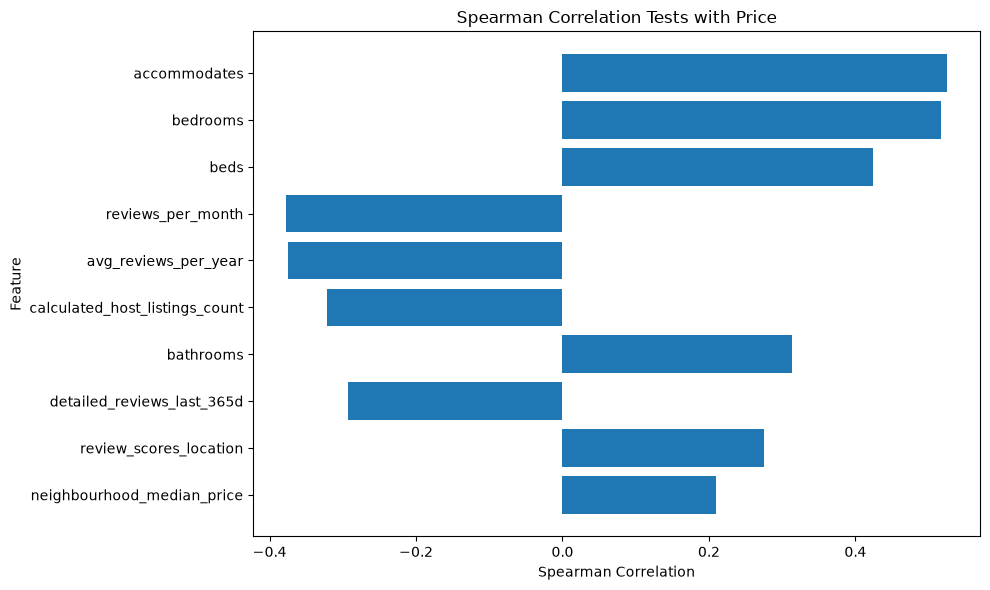

Saved figure to: ..\reports\statistical_analysis\spearman_price_correlation_tests.png


In [40]:
top_spearman_price_results = spearman_price_results_df.head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    top_spearman_price_results["feature"],
    top_spearman_price_results["spearman_correlation"]
)
plt.title("Spearman Correlation Tests with Price")
plt.xlabel("Spearman Correlation")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = STAT_REPORTS_PATH / "spearman_price_correlation_tests.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Spearman Correlation Test Interpretation

Spearman correlation tests were used to evaluate relationships between listing price and selected numeric features.

Property capacity features such as accommodates, bedrooms, beds, and bathrooms are expected to have positive relationships with price because larger listings can host more guests.

Review activity features may show negative relationships with price if lower-priced listings receive reviews more frequently due to higher booking turnover.

`estimated_revenue_proxy` was intentionally excluded from this test because it is calculated using price and would create target leakage for future machine learning.

### Spearman Correlation Test Interpretation

Spearman correlation testing shows that listing capacity features have the strongest positive relationship with price.  
Accommodates and bedrooms show strong positive correlations, while beds and bathrooms show moderate positive correlations.

Review activity features such as reviews per month and average reviews per year show moderate negative relationships with price.  
This may indicate that lower-priced listings receive reviews more frequently, possibly due to higher booking turnover.

Availability rate and occupancy proxy are statistically significant but have very weak relationships with price, so they should not be treated as major price drivers.

Estimated revenue proxy was excluded from this analysis because it is calculated using price and would create target leakage in future machine learning.